GULPS has two main stages: an LP that selects the gate sequence, and a numerical solver that finds the single-qubit corrections for each segment. This notebook benchmarks both stages, then compares GULPS against Qiskit's `XXDecomposer` and general-purpose synthesis tools (NuOp, BQSKit).

In [7]:
import time
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import lovelyplots
from tqdm import tqdm

from qiskit import QuantumCircuit
from qiskit.circuit.library import CXGate, UnitaryGate, iSwapGate
from qiskit.quantum_info import Operator, average_gate_fidelity, random_unitary
from qiskit.synthesis import XXDecomposer
from qiskit.converters import circuit_to_dag
from qiskit.transpiler import PassManager
from qiskit.transpiler.basepasses import TransformationPass

from gulps import GulpsDecomposer, GulpsDecompositionPass, GateInvariants, logger
from gulps.core.isa import DiscreteISA
from gulps.config import GulpsConfig
from gulps.comparisons.isa_library.benchmark_isas import (
    get_isa_scaling,
    get_depth_scaling,
)

logger.setLevel("WARNING")

### Complexity scaling

LP cost grows with |gate_set| because the sentence enumerator must reject more infeasible candidates before finding the cheapest feasible one. Segment solve time grows linearly with sentence depth because each segment is an independent Gauss-Newton solve. We measure both by sweeping progressive ISA families (iSwap, CX, mixed) and single-gate ISAs with shrinking fractional powers.

In [8]:
N_SAMPLES = 100
SEED_OFFSET = 0

# --- LP scaling: time vs |gate_set| ---
isa_configs = get_isa_scaling()
lp_results = []

for name, isa in tqdm(isa_configs, desc="LP scaling"):
    decomposer = GulpsDecomposer(
        isa=isa,
        config_options=GulpsConfig(flag_duration=0),
    )
    lp_times = []
    for idx in range(N_SAMPLES):
        target_inv = GateInvariants.from_unitary(
            random_unitary(4, seed=SEED_OFFSET + idx)
        )
        t0 = time.perf_counter()
        decomposer._best_decomposition(target_inv)
        lp_times.append(time.perf_counter() - t0)
    lp_results.append(
        {
            "name": name,
            "n_gates": len(isa.gate_set),
            "median": np.median(lp_times),
            "p95": np.percentile(lp_times, 95),
        }
    )

# --- Depth scaling: segment time vs sentence depth ---
depth_configs = get_depth_scaling()
depth_results = []

for name, isa in tqdm(depth_configs, desc="Depth scaling"):
    decomposer = GulpsDecomposer(
        isa=isa,
        config_options=GulpsConfig(flag_duration=0),
    )
    seg_times, depths, failures = [], [], 0
    for idx in range(N_SAMPLES):
        u = random_unitary(4, seed=SEED_OFFSET + idx)
        try:
            circ = decomposer(u)
            seg_times.append(decomposer.last_timing["segments"])
            depths.append(sum(1 for inst in circ if inst.operation.num_qubits == 2))
        except Exception:
            failures += 1
    depth_results.append(
        {
            "name": name,
            "median_seg": np.median(seg_times) if seg_times else np.nan,
            "p95_seg": np.percentile(seg_times, 95) if seg_times else np.nan,
            "median_depth": np.median(depths) if depths else np.nan,
            "failures": failures,
        }
    )
    if failures:
        print(f"  {name}: {failures}/{N_SAMPLES} failures")

Depth scaling: 100%|██████████| 14/14 [00:05<00:00,  2.75it/s]

  cx^1/8: 1/100 failures


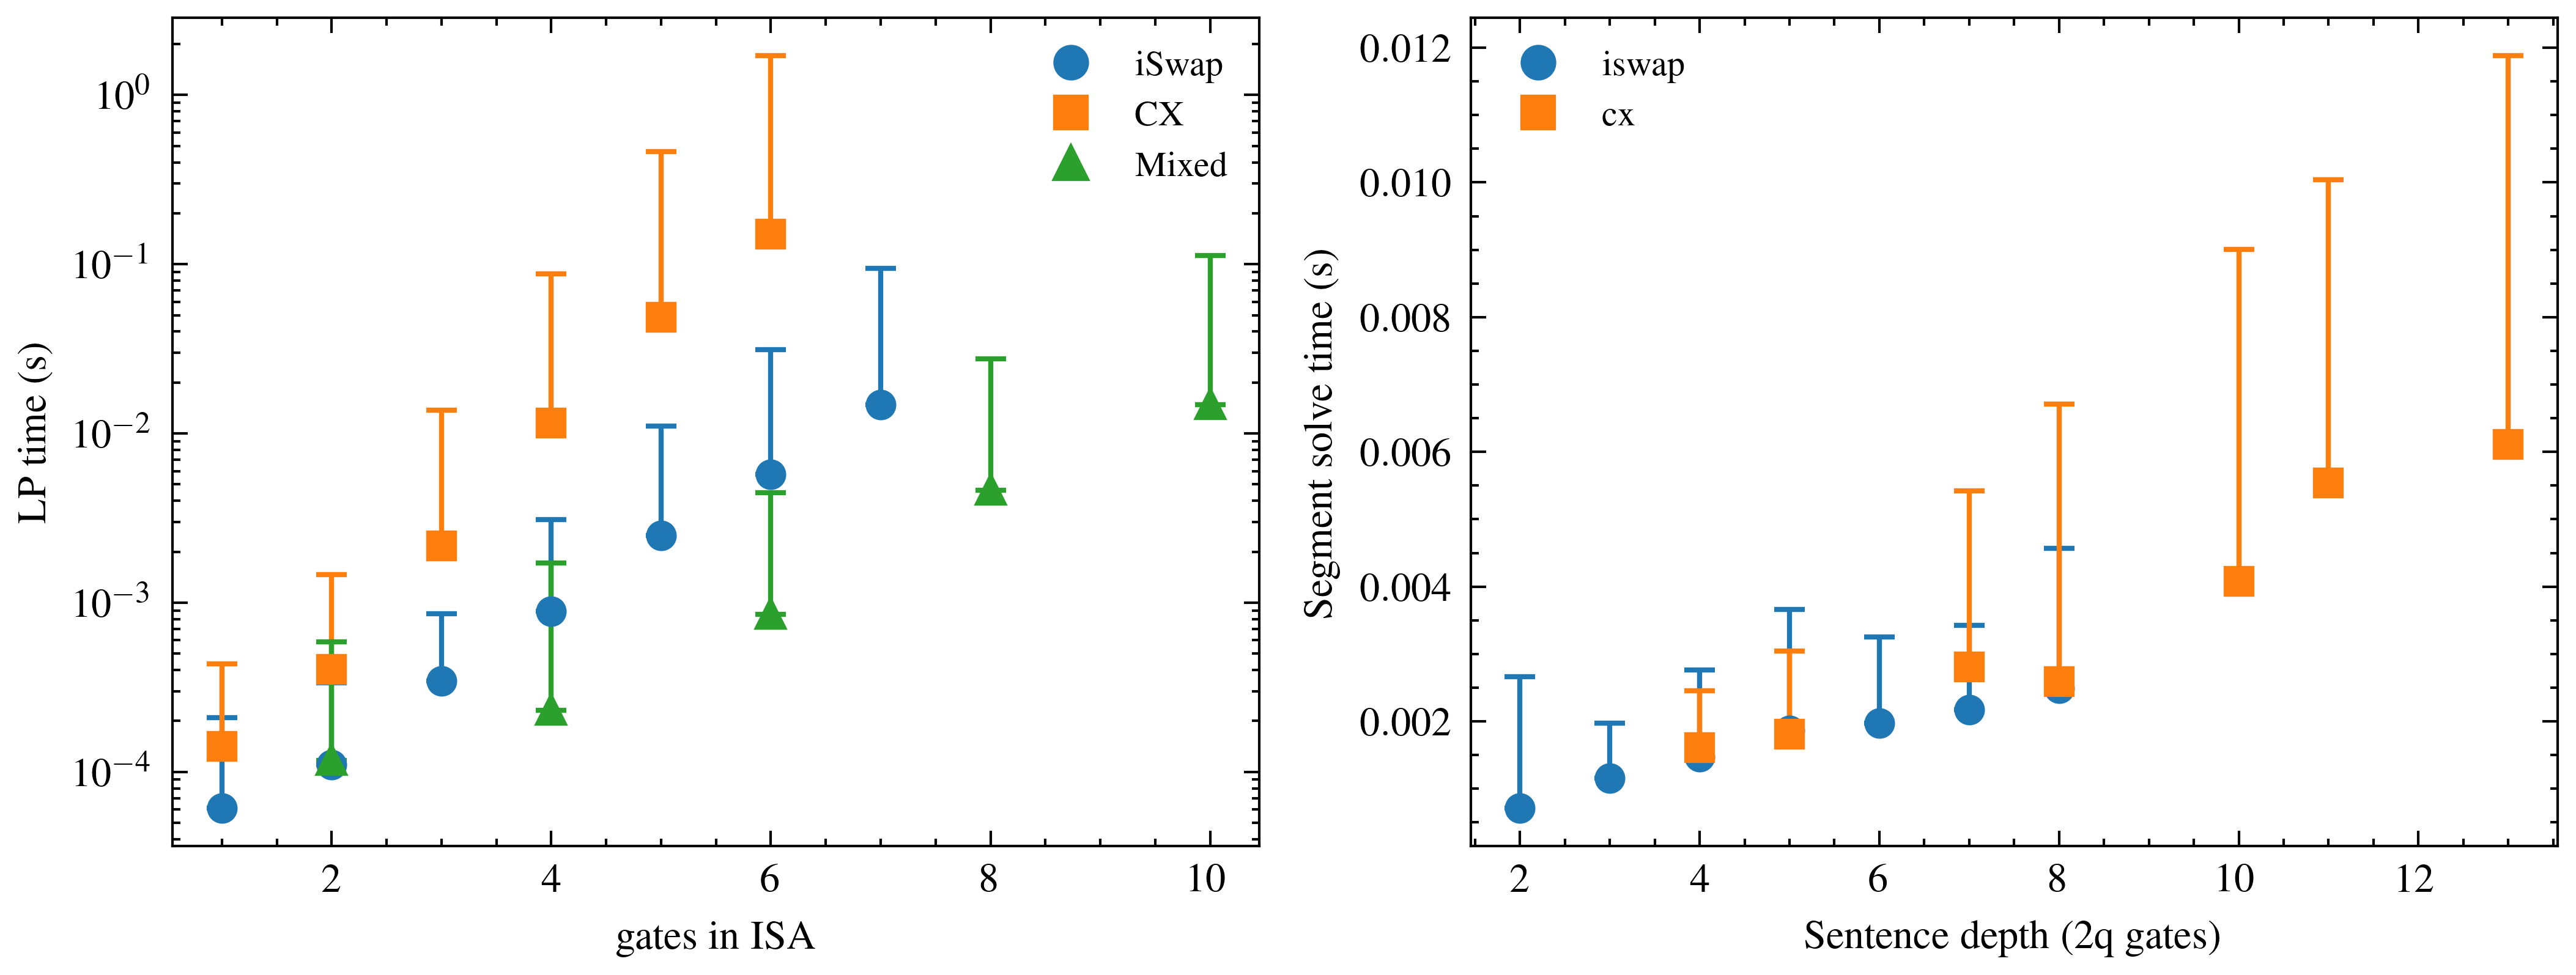

In [9]:
families = {
    "iswap_prog": {"color": "tab:blue", "marker": "o", "label": "iSwap"},
    "cx_prog": {"color": "tab:orange", "marker": "s", "label": "CX"},
    "mixed_prog": {"color": "tab:green", "marker": "^", "label": "Mixed"},
}
gate_families = {
    "iswap": {"color": "tab:blue", "marker": "o"},
    "cx": {"color": "tab:orange", "marker": "s"},
}

with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.16, 2.8))

    # Left: LP enumeration time vs |gate_set|
    for r in lp_results:
        fam = next((k for k in families if r["name"].startswith(k)), None)
        if fam is None:
            continue
        ax1.errorbar(
            r["n_gates"],
            r["median"],
            yerr=[[0], [r["p95"] - r["median"]]],
            fmt=families[fam]["marker"],
            color=families[fam]["color"],
            markersize=5,
            capsize=3,
        )
    for props in families.values():
        ax1.plot([], [], props["marker"], color=props["color"], label=props["label"])
    ax1.set_xlabel("gates in ISA")
    ax1.set_ylabel("LP time (s)")
    ax1.set_yscale("log")
    ax1.legend(fontsize=7)

    # Right: Segment solve time vs sentence depth
    for r in depth_results:
        if np.isnan(r["median_depth"]):
            continue
        fam = (
            "iswap"
            if r["name"].startswith("iswap")
            else "cx"
            if r["name"].startswith("cx")
            else None
        )
        if fam is None:
            continue
        ax2.errorbar(
            r["median_depth"],
            r["median_seg"],
            yerr=[[0], [r["p95_seg"] - r["median_seg"]]],
            fmt=gate_families[fam]["marker"],
            color=gate_families[fam]["color"],
            markersize=5,
            capsize=3,
        )
    for fam, props in gate_families.items():
        ax2.plot(
            [], [], props["marker"], color=props["color"], label=fam.replace("_", "\\_")
        )
    ax2.set_xlabel("Sentence depth (2q gates)")
    ax2.set_ylabel("Segment solve time (s)")
    ax2.legend(fontsize=7)

    fig.tight_layout()
    plt.show()

### GULPS vs XXDecomposer on fractional CX ISAs

Qiskit's `XXDecomposer` is an analytical decomposer for the CX/RZX gate family. It only handles gates of the form $e^{-i \theta XX}$. We compare total wall time across progressively richer CX-power ISAs on 1000 Haar-random targets.

In [10]:
N_XX = 1000
SEED_XX = 0
FULL_CX_INFIDELITY = 1e-10

ISA_TIERS = {
    "cx": [1.0],
    "sq2cx": [1 / 2],
    "sq3cx": [1 / 3],
    "sq4cx": [1 / 4],
    "sq{3,4}cx": [1 / 4, 1 / 3],
    "sq{2,4}cx": [1 / 4, 1 / 2],
    "sq{2,3,4}cx": [1 / 4, 1 / 3, 1 / 2],
    "cx+sq{2,3}": [1 / 3, 1 / 2, 1.0],
    "cx+sq{2,3,4}cx": [1 / 4, 1 / 3, 1 / 2, 1.0],
}


class XXDecompositionPass(TransformationPass):
    """Thin wrapper so XXDecomposer can run inside a PassManager."""

    def __init__(self, decomposer):
        super().__init__()
        self._dec = decomposer

    def run(self, dag):
        for node in dag.op_nodes():
            if node.op.num_qubits == 2 and not node.is_parameterized():
                dag.substitute_node_with_dag(
                    node, circuit_to_dag(self._dec(Operator(node.op)))
                )
        return dag


def _xx_basis_fidelity(powers):
    """XXDecomposer wants {strength: fidelity}."""
    f1 = 1.0 - FULL_CX_INFIDELITY
    return {p * np.pi / 2: float(np.clip(f1**p, 0, 1)) for p in powers}


def _bench_pm(pm, targets):
    """Time + fidelity for one PassManager on a batch of targets."""
    times, fids, fails = [], [], 0
    for u in targets:
        qc = QuantumCircuit(2)
        qc.append(UnitaryGate(Operator(u)), [0, 1])
        try:
            t0 = time.perf_counter()
            out = pm.run(qc)
            times.append(time.perf_counter() - t0)
            fids.append(average_gate_fidelity(u, Operator(out)))
        except Exception:
            fails += 1
    return times, fids, fails

In [11]:
targets_xx = [random_unitary(4, seed=s) for s in range(SEED_XX, SEED_XX + N_XX)]

results_xx = []
for isa_name, powers in ISA_TIERS.items():
    isa = DiscreteISA(
        gate_set=[CXGate().power(p) for p in powers],
        costs=powers,
        names=[f"cx^{p}" for p in powers],
        max_sequence_length=12,
    )
    gulps_pm = PassManager([GulpsDecompositionPass(GulpsDecomposer(isa=isa))])
    xx_pm = PassManager([XXDecompositionPass(XXDecomposer(_xx_basis_fidelity(powers)))])

    g_t, g_f, g_fail = _bench_pm(gulps_pm, targets_xx)
    x_t, x_f, x_fail = _bench_pm(xx_pm, targets_xx)

    g_ms, x_ms = np.sum(g_t) * 1e3, np.sum(x_t) * 1e3
    ratio = g_ms / x_ms
    print(f"{isa_name}: gulps {g_ms:.0f}ms  xx {x_ms:.0f}ms  ratio {ratio:.2f}x")

    results_xx.append(
        {"isa": isa_name, "gulps_total_ms": g_ms, "xx_total_ms": x_ms, "ratio": ratio}
    )

cx: gulps 1770ms  xx 2658ms  ratio 0.67x
sq2cx: gulps 1992ms  xx 3013ms  ratio 0.66x
sq3cx: gulps 2522ms  xx 4369ms  ratio 0.58x
sq4cx: gulps 3548ms  xx 5595ms  ratio 0.63x
sq{3,4}cx: gulps 4307ms  xx 6562ms  ratio 0.66x
sq{2,4}cx: gulps 2445ms  xx 6458ms  ratio 0.38x
sq{2,3,4}cx: gulps 4996ms  xx 8444ms  ratio 0.59x
cx+sq{2,3}: gulps 2541ms  xx 5017ms  ratio 0.51x
cx+sq{2,3,4}cx: gulps 5619ms  xx 8846ms  ratio 0.64x


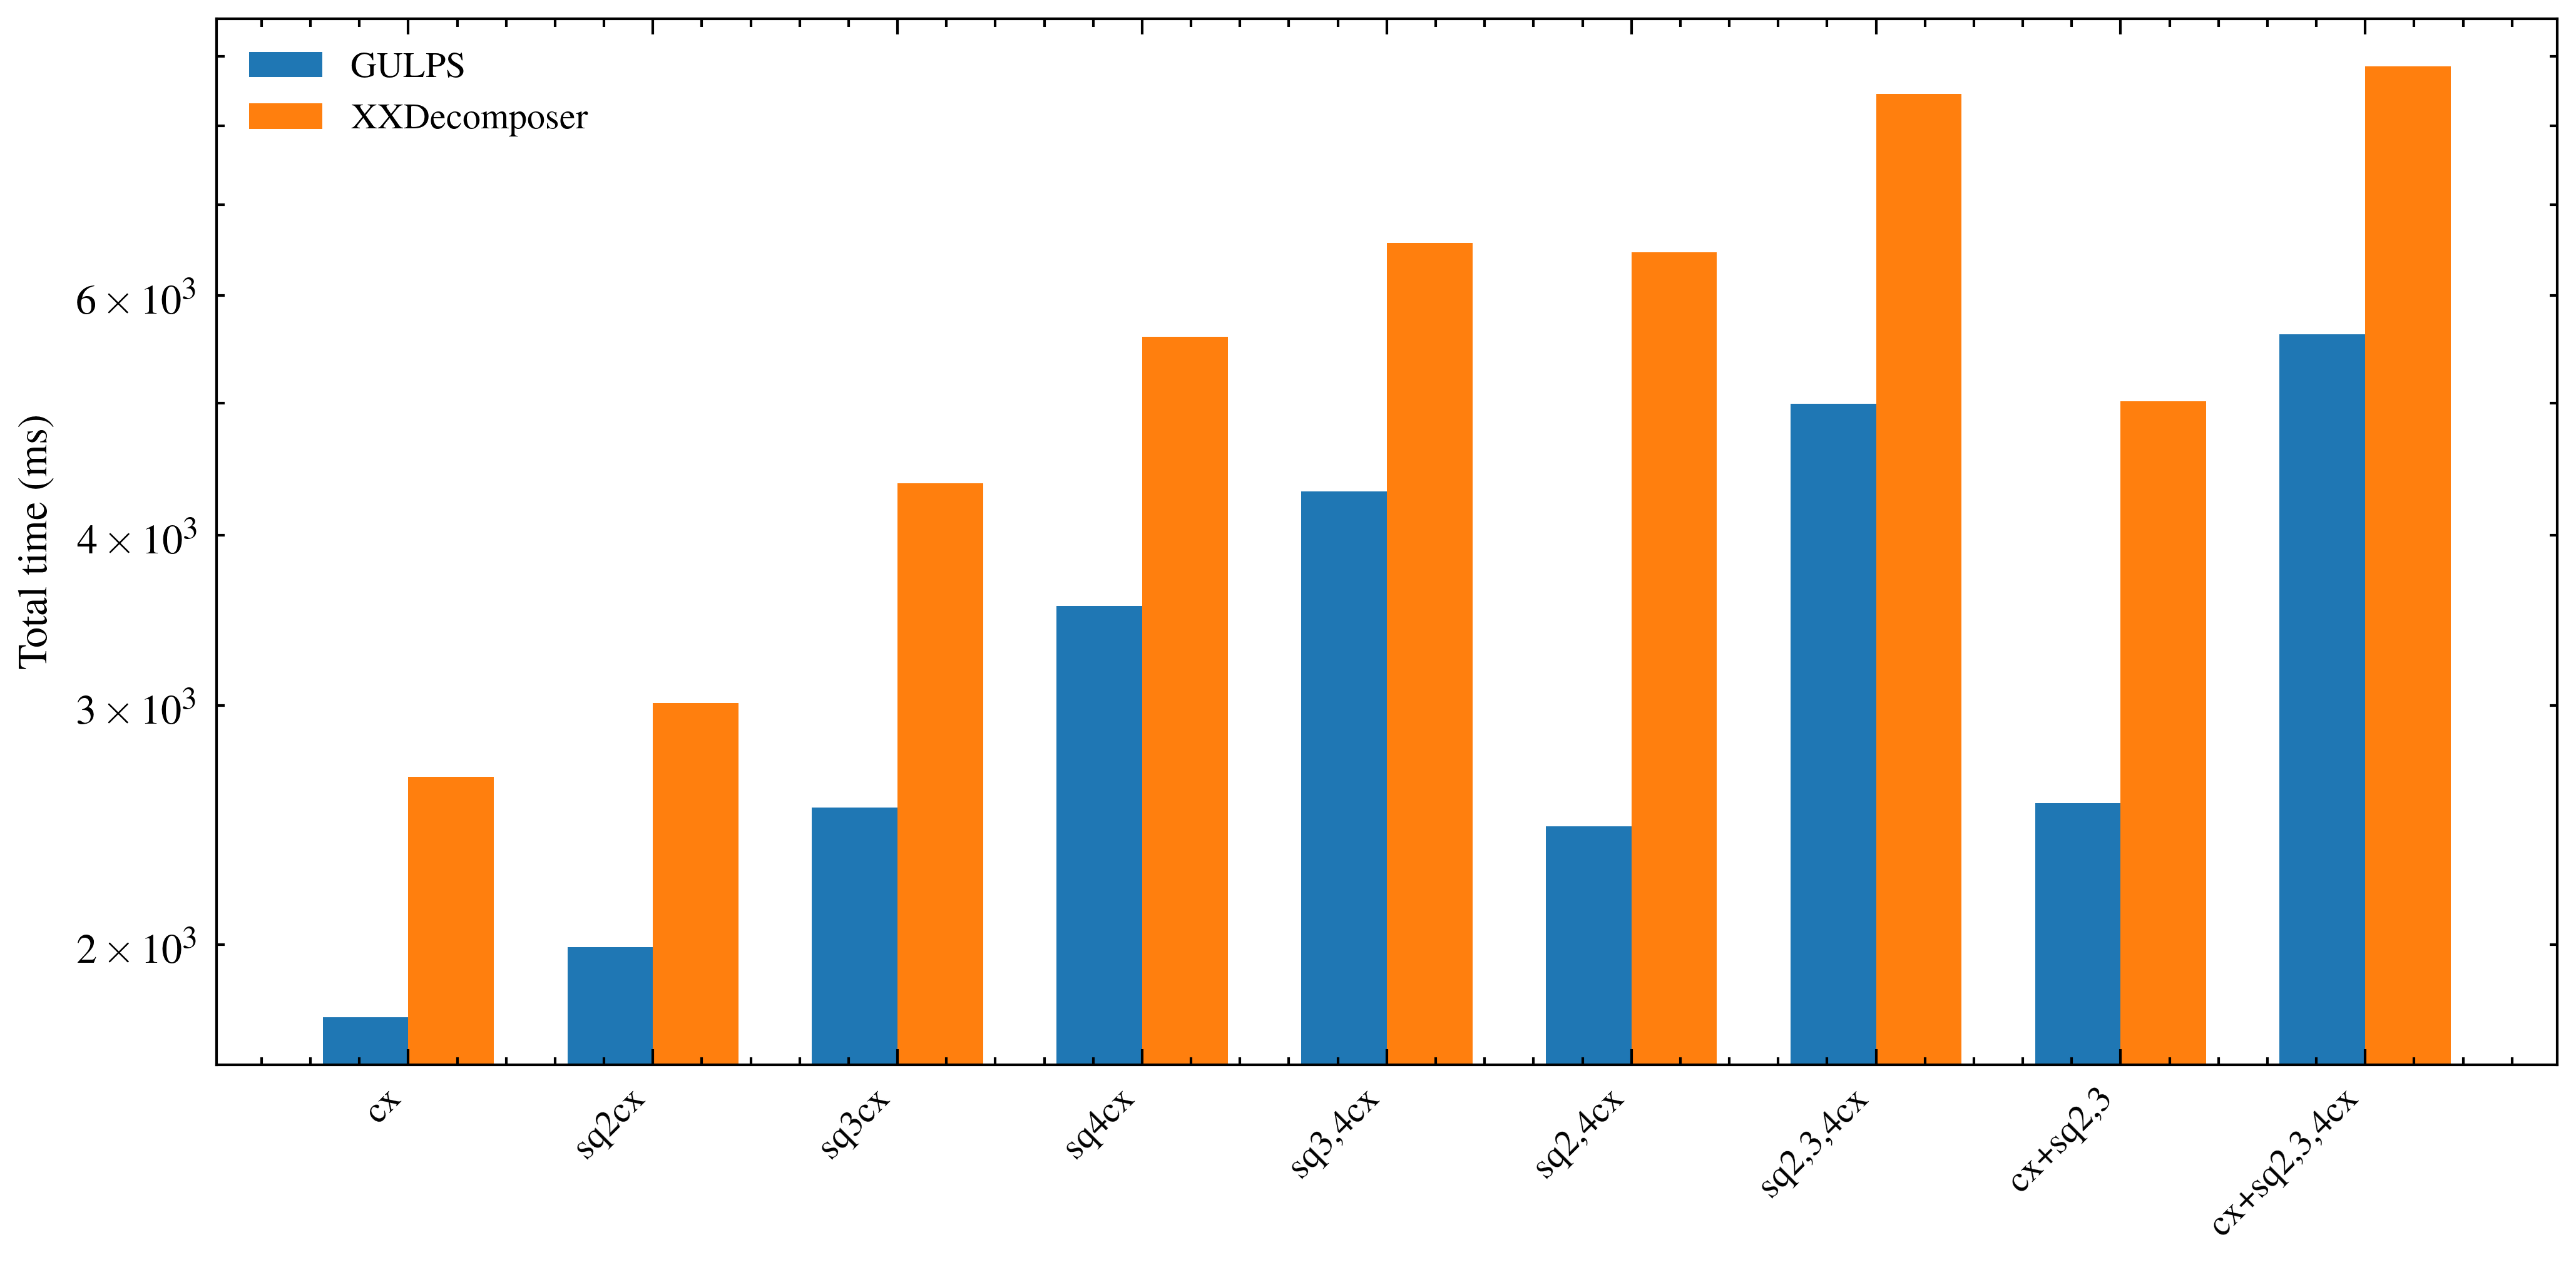

In [12]:
labels = [r["isa"] for r in results_xx]
gulps = [r["gulps_total_ms"] for r in results_xx]
xx = [r["xx_total_ms"] for r in results_xx]
x = np.arange(len(labels))
w = 0.35

with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(x - w / 2, gulps, w, label="GULPS", color="tab:blue")
    ax.bar(x + w / 2, xx, w, label="XXDecomposer", color="tab:orange")
    ax.set_ylabel("Total time (ms)")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax.legend(fontsize=7)
    ax.set_yscale("log")
    fig.tight_layout()
    plt.show()

### GULPS vs NuOp and BQSKit on fractional iSwap ISAs

`XXDecomposer` only handles the $XX$ (CX/RZX) family. Next, we compare to general basis synthesis tools: NuOp and BQSKit. These solve are orders of magnitude slower by construction because they don't exploit the strucutre of monodromy polytopes nor intermediate invariants. Requires `bqskit`.

In [ ]:
try:
    from bqskit import MachineModel, compile as bqskit_compile
    from bqskit.ir.gates import SqrtISwapGate, U3Gate
    from bqskit.qis.unitary.unitarymatrix import UnitaryMatrix
except ImportError:
    print("BQSKit python package not found.")

from gulps.comparisons.nuop_driver import (
    xy_gate,
    ParallelGateReplacementPass,
)
from gulps.comparisons.bqskit_driver import Sqrt3iSwapGate, Sqrt4iSwapGate

In [26]:
N_SAMPLES = 5
SEED_OFFSET = 0
DECOMPOSERS = ["gulps", "nuop", "bqskit"]
LABELS = {"gulps": "GULPS", "nuop": "NuOp", "bqskit": "BQSKit"}
COLORS = {"gulps": "tab:blue", "nuop": "tab:orange", "bqskit": "tab:green"}

# --- ISA definitions ---
# Each ISA maps the same physical gates into each decomposer's native format.
# NuOp uses ParallelGateReplacementPass which natively handles hetero gate sets:
#   it tries every gate type for each 2Q operation and picks the best fidelity.
ISA_CONFIGS = [
    # ── Homogeneous ISAs ──
    {
        "name": r"iSwap$^{1/2}$",
        "gulps": {
            "gate_set": [iSwapGate().power(1 / 2)],
            "costs": [0.5],
            "names": ["sq2iswap"],
        },
        "nuop": {
            "gate_defs": [xy_gate],
            "gate_params": [[np.pi / 2]],
            "gate_labels": ["sq2iswap"],
            "costs": {"sq2iswap": 0.5},
        },
        "bqskit": {
            "gate_set": {SqrtISwapGate(), U3Gate()},
            "cost_map": {SqrtISwapGate: 0.5},
        },
    },
    {
        "name": r"iSwap$^{1/3}$",
        "gulps": {
            "gate_set": [iSwapGate().power(1 / 3)],
            "costs": [1 / 3],
            "names": ["sq3iswap"],
        },
        "nuop": {
            "gate_defs": [xy_gate],
            "gate_params": [[np.pi / 3]],
            "gate_labels": ["sq3iswap"],
            "costs": {"sq3iswap": 1 / 3},
        },
        "bqskit": {
            "gate_set": {Sqrt3iSwapGate(), U3Gate()},
            "cost_map": {Sqrt3iSwapGate: 1 / 3},
        },
    },
    {
        "name": r"iSwap$^{1/4}$",
        "gulps": {
            "gate_set": [iSwapGate().power(1 / 4)],
            "costs": [0.25],
            "names": ["sq4iswap"],
        },
        "nuop": {
            "gate_defs": [xy_gate],
            "gate_params": [[np.pi / 4]],
            "gate_labels": ["sq4iswap"],
            "costs": {"sq4iswap": 0.25},
        },
        "bqskit": {
            "gate_set": {Sqrt4iSwapGate(), U3Gate()},
            "cost_map": {Sqrt4iSwapGate: 0.25},
        },
    },
    # ── Heterogeneous ISAs ──
    {
        "name": r"iSwap$^{1/2}$ + iSwap$^{1/3}$",
        "gulps": {
            "gate_set": [iSwapGate().power(1 / 2), iSwapGate().power(1 / 3)],
            "costs": [0.5, 1 / 3],
            "names": ["sq2iswap", "sq3iswap"],
        },
        "nuop": {
            "gate_defs": [xy_gate, xy_gate],
            "gate_params": [[np.pi / 2], [np.pi / 3]],
            "gate_labels": ["sq2iswap", "sq3iswap"],
            "costs": {"sq2iswap": 0.5, "sq3iswap": 1 / 3},
        },
        "bqskit": {
            "gate_set": {SqrtISwapGate(), Sqrt3iSwapGate(), U3Gate()},
            "cost_map": {SqrtISwapGate: 0.5, Sqrt3iSwapGate: 1 / 3},
        },
    },
    {
        "name": r"iSwap$^{1/2}$ + iSwap$^{1/3}$ + iSwap$^{1/4}$",
        "gulps": {
            "gate_set": [
                iSwapGate().power(1 / 2),
                iSwapGate().power(1 / 3),
                iSwapGate().power(1 / 4),
            ],
            "costs": [0.5, 1 / 3, 0.25],
            "names": ["sq2iswap", "sq3iswap", "sq4iswap"],
        },
        "nuop": {
            "gate_defs": [xy_gate, xy_gate, xy_gate],
            "gate_params": [[np.pi / 2], [np.pi / 3], [np.pi / 4]],
            "gate_labels": ["sq2iswap", "sq3iswap", "sq4iswap"],
            "costs": {"sq2iswap": 0.5, "sq3iswap": 1 / 3, "sq4iswap": 0.25},
        },
        "bqskit": {
            "gate_set": {SqrtISwapGate(), Sqrt3iSwapGate(), Sqrt4iSwapGate(), U3Gate()},
            "cost_map": {
                SqrtISwapGate: 0.5,
                Sqrt3iSwapGate: 1 / 3,
                Sqrt4iSwapGate: 0.25,
            },
        },
    },
]

In [38]:
def _bench_gulps(cfg, targets, name):
    dec = GulpsDecomposer(
        gate_set=cfg["gate_set"], costs=cfg["costs"], names=cfg["names"]
    )
    _ = dec(random_unitary(4, seed=999))  # JIT warmup
    times, costs, fids = [], [], []
    for u in tqdm(targets, desc=f"{name} / GULPS"):
        target_inv = GateInvariants.from_unitary(u)
        sol = dec._best_decomposition(target_inv)
        t0 = time.perf_counter()
        qc = dec(u)
        times.append(time.perf_counter() - t0)
        fids.append(average_gate_fidelity(u, Operator(qc)))
        costs.append(sol.cost)
    return {"times": times, "costs": costs, "fidelities": fids}


def _bench_nuop(cfg, targets, name):
    n = len(cfg["gate_defs"])
    dec = ParallelGateReplacementPass(
        gate_defs=cfg["gate_defs"],
        gate_params=cfg["gate_params"],
        gate_labels=cfg["gate_labels"],
        fidelity_dict_2q_gate={(0, 1): [1.0] * n},
        fidelity_list_1q_gate=[1.0, 1.0],
        tol=0.0,
    )
    wqc = QuantumCircuit(2)
    wqc.append(random_unitary(4, seed=999), [0, 1])
    _ = dec.run(wqc, exact_decom=True)  # warmup

    times, costs, fids = [], [], []
    for u in tqdm(targets, desc=f"{name} / NuOp"):
        qc = QuantumCircuit(2)
        qc.append(u, [0, 1])
        t0 = time.perf_counter()
        out = dec.run(qc, exact_decom=True)
        times.append(time.perf_counter() - t0)
        fids.append(average_gate_fidelity(Operator(qc), Operator(out)))
        costs.append(
            sum(
                cfg["costs"].get(i.operation.label, 0) for i in out if i.operation.label
            )
        )
    return {"times": times, "costs": costs, "fidelities": fids}


def _bench_bqskit(cfg, targets, name):
    model = MachineModel(2, gate_set=cfg["gate_set"])
    _ = bqskit_compile(UnitaryMatrix(random_unitary(4, seed=999).data), model=model)

    times, costs, fids = [], [], []
    for u in tqdm(targets, desc=f"{name} / BQSKit"):
        mat = np.array(u.to_matrix())
        t0 = time.perf_counter()
        out = bqskit_compile(UnitaryMatrix(mat), model=model)  # cache the compiler
        times.append(time.perf_counter() - t0)
        cost = sum(
            count * cfg["cost_map"].get(type(g), 0)
            for g, count in out.gate_counts.items()
            if g.num_qudits == 2
        )
        costs.append(cost)
        fids.append(
            average_gate_fidelity(Operator(mat), Operator(out.get_unitary()._utry))
        )
    return {"times": times, "costs": costs, "fidelities": fids}

In [40]:
targets_cross = [random_unitary(4, seed=s) for s in range(0, 0 + 5)]

all_results = {}
for cfg in ISA_CONFIGS:
    name = cfg["name"]
    print(f"\n=== ISA: {name} ===")
    all_results[name] = {
        "gulps": _bench_gulps(cfg["gulps"], targets_cross, name),
        # "nuop": _bench_nuop(cfg["nuop"], targets_cross, name),
        "bqskit": _bench_bqskit(cfg["bqskit"], targets_cross, name),
    }


=== ISA: iSwap$^{1/2}$ ===


iSwap$^{1/2}$ / BQSKit: 100%|██████████| 5/5 [00:17<00:00,  3.41s/it]



=== ISA: iSwap$^{1/3}$ ===


iSwap$^{1/3}$ / BQSKit: 100%|██████████| 5/5 [01:06<00:00, 13.30s/it]



=== ISA: iSwap$^{1/4}$ ===


iSwap$^{1/4}$ / BQSKit: 100%|██████████| 5/5 [01:09<00:00, 13.83s/it]



=== ISA: iSwap$^{1/2}$ + iSwap$^{1/3}$ ===


iSwap$^{1/2}$ + iSwap$^{1/3}$ / BQSKit: 100%|██████████| 5/5 [01:02<00:00, 12.49s/it]



=== ISA: iSwap$^{1/2}$ + iSwap$^{1/3}$ + iSwap$^{1/4}$ ===


iSwap$^{1/2}$ + iSwap$^{1/3}$ + iSwap$^{1/4}$ / GULPS: 100%|██████████| 5/5 [00:00<00:00, 261.96it/s]
iSwap$^{1/2}$ + iSwap$^{1/3}$ + iSwap$^{1/4}$ / BQSKit: 100%|██████████| 5/5 [01:09<00:00, 13.83s/it]


In [48]:
_pruned = [DECOMPOSERS[0], DECOMPOSERS[2]]

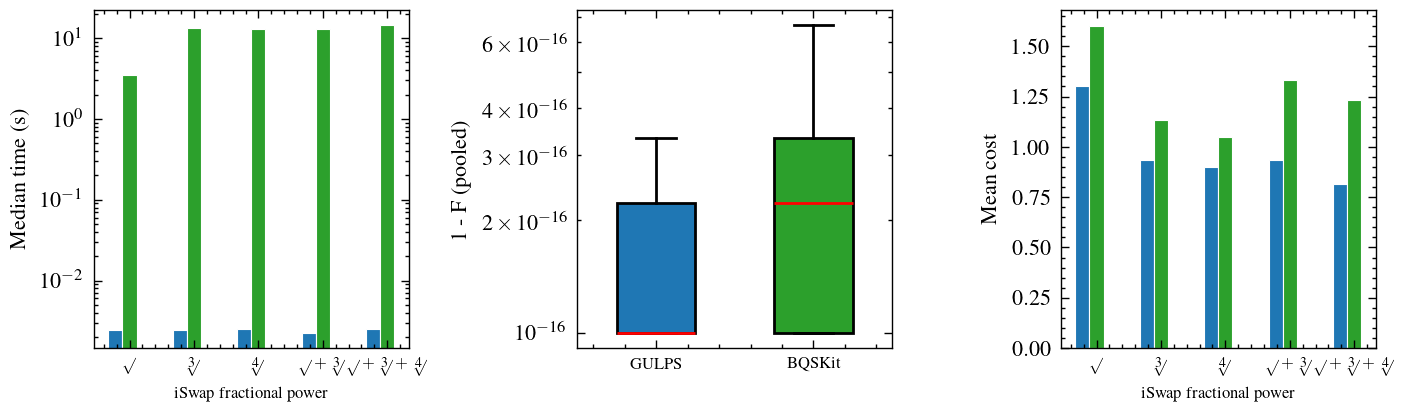

In [50]:
n_isas = len(ISA_CONFIGS)
INFIDELITY_FLOOR = 1e-16

ISA_SHORT = [
    r"$\sqrt{}$",
    r"$\sqrt[3]{}$",
    r"$\sqrt[4]{}$",
    r"$\sqrt{}+\sqrt[3]{}$",
    r"$\sqrt{}+\sqrt[3]{}+\sqrt[4]{}$",
]

with plt.style.context(["science", "ieee", "use_mathtext"]):
    fig, (ax_time, ax_fid, ax_cost) = plt.subplots(1, 3, figsize=(7.16, 2.2), dpi=200)
    x = np.arange(n_isas)
    isa_names = [cfg["name"] for cfg in ISA_CONFIGS]
    w = 0.22

    for i, d in enumerate(_pruned):
        vals = [np.median(all_results[name][d]["times"]) for name in isa_names]
        ax_time.bar(
            x + (i - 1) * w,
            vals,
            w,
            color=COLORS[d],
            edgecolor="white",
            linewidth=0.4,
            label=LABELS[d],
        )
    ax_time.set_yscale("log")
    ax_time.set_ylabel("Median time (s)")
    ax_time.set_xticks(x)
    ax_time.set_xticklabels(ISA_SHORT, fontsize=6)
    ax_time.set_xlabel("iSwap fractional power", fontsize=6)

    infid_data = []
    for d in _pruned:
        pool = []
        for name in isa_names:
            pool.extend(
                np.clip(
                    1 - np.array(all_results[name][d]["fidelities"]),
                    INFIDELITY_FLOOR,
                    None,
                )
            )
        infid_data.append(pool)
    bp = ax_fid.boxplot(
        infid_data, vert=True, patch_artist=True, widths=0.5, showfliers=False
    )
    for patch, d in zip(bp["boxes"], _pruned):
        patch.set_facecolor(COLORS[d])
    ax_fid.set_yscale("log")
    ax_fid.set_ylabel("1 - F (pooled)")
    ax_fid.set_xticklabels([LABELS[d] for d in _pruned], fontsize=6)

    for i, d in enumerate(_pruned):
        vals = [np.mean(all_results[name][d]["costs"]) for name in isa_names]
        ax_cost.bar(
            x + (i - 1) * w, vals, w, color=COLORS[d], edgecolor="white", linewidth=0.4
        )
    ax_cost.set_ylabel("Mean cost")
    ax_cost.set_xticks(x)
    ax_cost.set_xticklabels(ISA_SHORT, fontsize=6)
    ax_cost.set_xlabel("iSwap fractional power", fontsize=6)

    fig.tight_layout()
    plt.show()